# Deep Variational Encoder with Fixed Prior

## Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
os.environ["ENABLE_PJRT_COMPATIBILITY"] = "1"


from model import VaDE
from train import VaDE_trainer
from utils import image_to_jax1d, jax_collate_fn, plot_image

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flax import nnx
import optax
import pcax
import matplotlib.pyplot as plt

os.environ['JAX_PLATFORMS'] = 'cpu'

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal

## Training model

In [3]:
train_dataset = MNIST(root = "./../data", train = True, download = True, transform = image_to_jax1d)
test_dataset = MNIST(root = "./../data", train = False, download = True, transform = image_to_jax1d)

train_data_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)
test_data_loader = DataLoader(test_dataset, batch_size = 128, shuffle = True, collate_fn = jax_collate_fn)

In [4]:
in_dim = 28*28
latent_dim = 16
hidden_dim = 256
rngs = nnx.Rngs(0)
learning_rate = 0.001
K = 10
epochs = 10

In [5]:
model = VaDE(in_dim = in_dim, latent_dim = latent_dim, hidden_dim = hidden_dim, K = K, rngs = rngs, learn_prior= False)
optimizer = nnx.Optimizer(model, optax.adam(learning_rate), wrt = nnx.Param)
trainer = VaDE_trainer(model, optimizer)

In [6]:
train_history, eval_history = trainer.train(epochs, train_data_loader, test_data_loader)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [06:02<00:00, 36.30s/it]


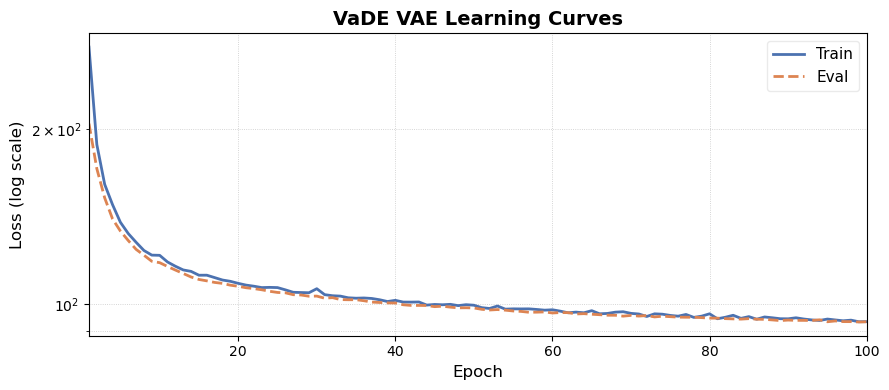

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_range = range(1, len(train_history) + 1)

ax.plot(epochs_range, train_history, color="#4C72B0", linewidth=2, label="Train")
ax.plot(epochs_range, eval_history,  color="#DD8452", linewidth=2, linestyle="--", label="Eval")

ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("VaDE VAE Learning Curves", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, framealpha=0.4)
ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
ax.set_xlim(1, len(train_history))

fig.tight_layout()
plt.show()

## Reconstruction test

In [8]:
x = next(iter(train_data_loader))[0][:5]
keys = jr.split(jr.PRNGKey(0), 5)
x_rec = jax.vmap(lambda xi, k: model(xi, k))(x, keys)

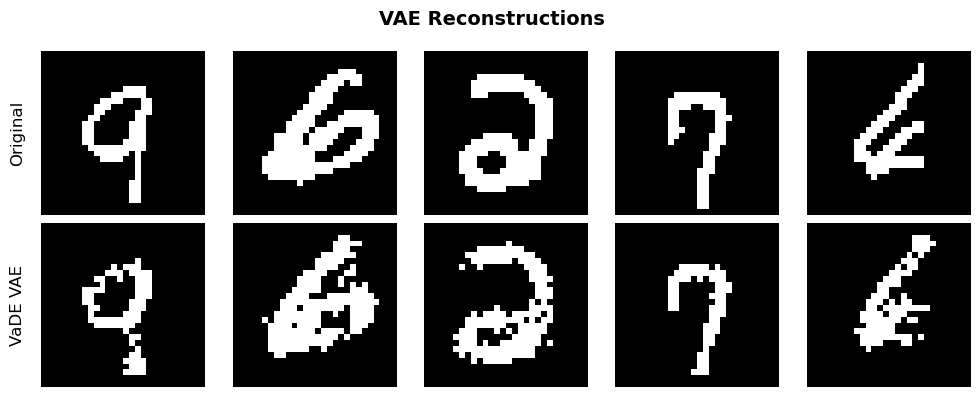

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

row_labels = ["Original", "VaDE VAE"]
rows = [x, x_rec]

for row_idx, (label, row_data) in enumerate(zip(row_labels, rows)):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        plot_image(row_data[col_idx], ax=ax)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.1, 0.5, label,
        transform=axes[row_idx, 0].transAxes,
        fontsize=12, va="center", ha="right", rotation=90
    )

fig.suptitle("VAE Reconstructions", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Image generation

In [10]:
keys = jr.split(jr.PRNGKey(0), 5)
gen  = jnp.stack([model.generate(k)  for k in keys])

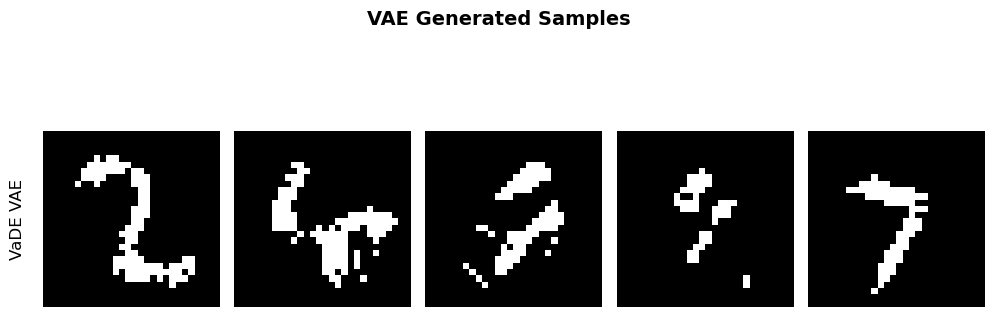

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(10, 4))

row_label = "VaDE VAE"
row_data = gen

for col_idx in range(5):
    ax = axes[col_idx]
    plot_image(row_data[col_idx], ax=ax)
    ax.axis("off")
axes[0].text(
    -0.1, 0.5, row_label,
    transform=axes[0].transAxes,
    fontsize=12, va="center", ha="right", rotation=90
)

fig.suptitle("VAE Generated Samples", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Visualization of latent space

In [12]:
x = jnp.concatenate([batch[0] for batch in train_data_loader], axis=0)
labels = jnp.concatenate([batch[1] for batch in train_data_loader], axis=0)

In [13]:
keys = jr.split(jr.PRNGKey(0), x.shape[0])
z = jax.vmap(model.encode)(x, keys)


In [14]:
state = pcax.fit(z, n_components=2)
z_pca = pcax.transform(state, z)

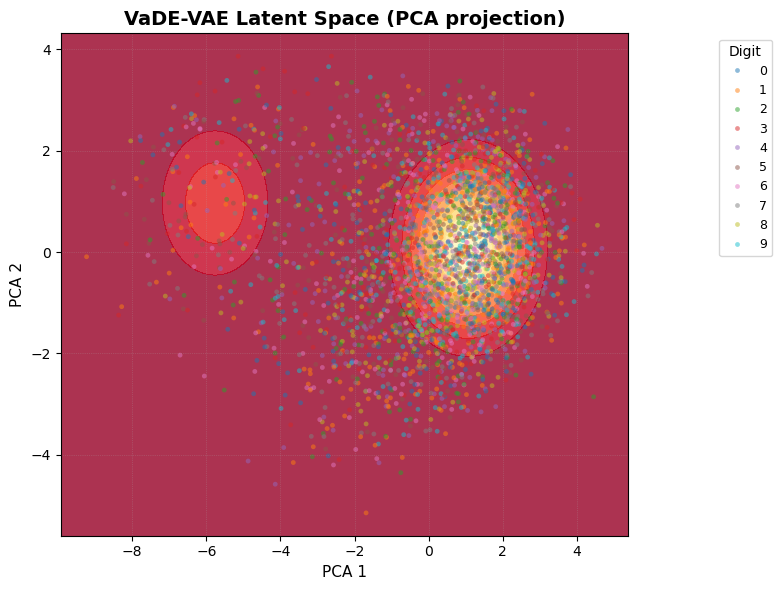

In [15]:
N_SCATTER = 3000

def make_df(z_pca, labels, n=N_SCATTER):
    idx = np.random.choice(len(z_pca), size=n, replace=False)
    return pd.DataFrame({
        "PCA 1": np.array(z_pca[idx, 0]),
        "PCA 2": np.array(z_pca[idx, 1]),
        "Digit": np.array(labels[idx]).astype(str),
    })

df = make_df(z_pca, labels)

# Recover PCA projection matrix V (latent_dim x 2) from the data
z_np = np.array(z)
z_pca_np = np.array(z_pca)
z_mean = z_np.mean(axis=0)
V, _, _, _ = np.linalg.lstsq(z_np - z_mean, z_pca_np, rcond=None)  # (latent_dim, 2)

# Build grid over the data range
x_min, x_max = df["PCA 1"].min(), df["PCA 1"].max()
y_min, y_max = df["PCA 2"].min(), df["PCA 2"].max()
margin_x, margin_y = (x_max - x_min) * 0.05, (y_max - y_min) * 0.05
xx, yy = np.meshgrid(
    np.linspace(x_min - margin_x, x_max + margin_x, 100),
    np.linspace(y_min - margin_y, y_max + margin_y, 100),
)
grid_2d = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (n_pts, 2)

# Inverse PCA: map 2D grid points back to latent space
grid_latent = jnp.array(z_mean + grid_2d @ V.T)  # (n_pts, latent_dim)

# Evaluate the VaDE prior density on the grid using model.prior_pdf
zz = np.array(jax.vmap(model.prior_pdf)(grid_latent)).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)
# Removed color bar as requested

sns.scatterplot(
    data=df, x="PCA 1", y="PCA 2", hue="Digit",
    palette=sns.color_palette("tab10", 10), alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax,
)

ax.set_title("VaDE-VAE Latent Space (PCA projection)", fontsize=14, fontweight="bold")
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(title="Digit", bbox_to_anchor=(1.15, 1), loc="upper left", fontsize=9)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
fig.tight_layout()
plt.show()

In [16]:
alphas = jax.nn.softmax(model.logit_alpha_gmm.get_value())
mu = model.mu_gmm.get_value()


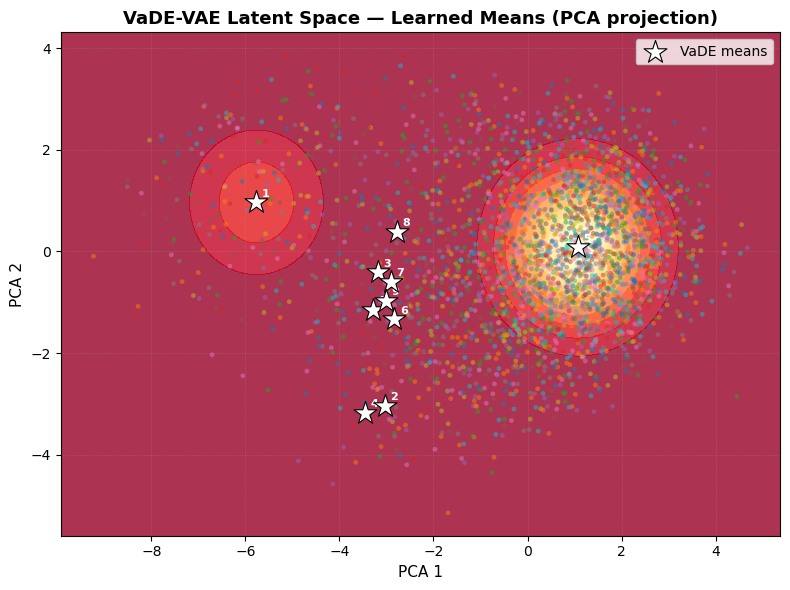

In [17]:
# Project mu_VaDE to 2D PCA space (reuses z_mean and V from the PCA cell)
mu_np = np.array(mu)
mu_pca = (mu_np - z_mean) @ V  # (K, 2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cf = ax.contourf(xx, yy, zz, levels=12, cmap="YlOrRd_r", alpha=0.8)

sns.scatterplot(
    data=df, x="PCA 1", y="PCA 2", hue="Digit",
    palette=sns.color_palette("tab10", 10), alpha=0.5, s=12, linewidth=0,
    hue_order=[str(i) for i in range(10)], ax=ax, legend=False,
)

ax.scatter(
    mu_pca[:, 0], mu_pca[:, 1],
    marker="*", s=300, c="white", edgecolors="black", linewidths=0.8,
    zorder=5, label="VaDE means",
)
for k in range(len(mu_pca)):
    ax.annotate(str(k), xy=(mu_pca[k, 0], mu_pca[k, 1]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=8, color="white", fontweight="bold")

ax.set_title("VaDE-VAE Latent Space — Learned Means (PCA projection)", fontsize=13, fontweight="bold")
ax.set_xlabel("PCA 1", fontsize=11)
ax.set_ylabel("PCA 2", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
fig.tight_layout()
plt.show()